In [ ]:
netlist = """\
RC Transient Circuit
Vin in 0 PULSE(0 5 0 1n 1n $PULSE_WIDTH $PERIOD)
R1 in out $R
C1 out 0 $C

.TRAN $TSTEP $TEND $TSTART

.SAVE $SAVE_VARS
.END
"""

with open('rc_tran_orig.cir', 'w') as f:
    f.write(netlist)

print("rc_tran_orig.cir written")

rc_tran_orig.cir written


In [ ]:
import ngspice_calc as calc
import numpy as np
import matplotlib.pyplot as plt

R = 1e3
C = 1e-6
tau = R * C

period = 10 * tau
pulse_width = period/2
tstep = tau/100
tend = 3*period
tstart = 1*period

print(f'Time constant: {tau*1e3:.2f}ms')
print(f'Period: {period*1e3:.2f}ms')
print(f'Output has data from {tstart*1e3:.2f}ms to {tend*1e3:.2f}ms')

Time constant: 1.00ms
Period: 10.00ms
Output has data from 10.00ms to 30.00ms


In [ ]:
l = [
    ('$R', f'{R:.0f}'),
    ('$C', f'{C:.2e}'),
    ('$PULSE_WIDTH', f'{pulse_width:.8f}'),
    ('$PERIOD', f'{period:.8f}'),
    ('$TSTEP', f'{tstep:.8f}'),
    ('$TEND', f'{tend:.8f}'),
    ('$TSTART', f'{tstart:.8f}'),
    ('$SAVE_VARS', f'v(in) v(out)')
]

calc.replace_strings_1('rc_tran_orig.cir', 'rc_tran.cir', l)
calc.run_ngspice('rc_tran.cir')


Note: No compatibility mode selected!


Circuit: rc transient circuit

binary raw file "rc_tran.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver
No. of Data Columns : 3  

Initial Transient Solution
--------------------------

Node                                   Voltage
----                                   -------
in                                           0
out                                          0
vin#branch                                   0


No. of Data Rows : 2085

Total analysis time (seconds) = 0.0102872

Total elapsed time (seconds) = 0.014 

Total DRAM available = 15614.738 MB.
DRAM currently available = 3758.742 MB.
Maximum ngspice program size =   21.406 MB.
Current ngspice program size =   12.727 MB.

Shared ngspice pages =   10.949 MB.
Text (code) pages =    7.105 MB.
Stack = 0 bytes.
Library pages =    1.879 MB.




'rc_tran.raw'

In [ ]:
s = calc.slv('rc_tran.cir')

for i in range(s.num_plots()):
    print(f"plot {i}: {s.plotname(i)} | type: {s.analysis_type(i)} | vars: {s.variables(i)}")

plot 0: Transient Analysis | type: tran | vars: ['time', 'v(in)', 'v(out)']


In [ ]:
t = s.get_array('time')
v_in = s.get_array('v(in)')
v_out = s.get_array('v(out)')

print(f"Time range: {t[0]*1e3:.2f} ms to {t[-1]*1e3:.2f} ms")
print(f"Number of points: {len(t)}")

Time range: 10.00 ms to 30.00 ms
Number of points: 2085


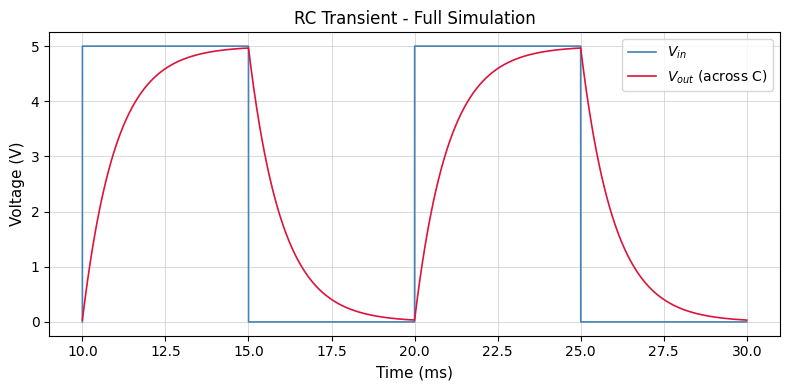

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.grid(which='both', color='#CCCCCC', linestyle='solid', linewidth=0.5)
ax.plot(t*1e3, v_in,  color='steelblue', linewidth=1.2, label=r'$V_{in}$')
ax.plot(t*1e3, v_out, color='crimson',   linewidth=1.2, label=r'$V_{out}$ (across C)')
ax.set_xlabel('Time (ms)', fontsize=11)
ax.set_ylabel('Voltage (V)', fontsize=11)
ax.set_title('RC Transient - Full Simulation', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()